In [2]:
import pandas as pd
import matplotlib.pyplot as plt
#DTC class implements DT algorithms
from sklearn.tree import DecisionTreeClassifier, plot_tree
#import train_test_split to split dataset into training and testing sets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


dropout_data = pd.read_csv('sdropout.csv')
#X are the data inputs used to train the model
X = dropout_data.drop(columns =['Dropout'])
#y indicates the output(predictions)
y = dropout_data['Dropout'] 

#use 20% of data for testing, 80% for training
# X_train,X_test are inputs for traning and testing
# y_train,y_test are outputs for traning and testing
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)


# Handle categorical data(strings->numerical data)
X_train = pd.get_dummies(X_train)
#reindex method ensure the columns of new instances matched data's columns used to train
X_test = pd.get_dummies(X_test).reindex(columns=X_train.columns, fill_value=0)

dropout_data.describe()


,Age,SleepingHours,GamingHours,Distance,AverageScore
count,144.000000,144.000000,144.000000,144.000000,144.000000
mean,25.527778,5.090278,1.885417,59.850139,7.340278
std,4.222723,0.880346,1.195444,16.083897,1.028701
min,18.000000,3.500000,0.500000,28.560000,5.400000
25%,22.000000,4.500000,1.000000,48.682500,6.600000
50%,25.000000,5.000000,1.500000,60.770000,7.500000
75%,29.000000,6.000000,3.000000,72.652500,8.100000
max,33.000000,6.500000,4.000000,93.720000,9.500000


In [3]:
dropout_data.shape

(144, 8)

In [4]:
dropout_data.values

array([['F', 23, 5.5, ..., 38.12, 8.1, 'No'],
       ['M', 26, 5.0, ..., 56.74, 7.8, 'No'],
       ['M', 29, 4.0, ..., 75.82, 6.4, 'Yes'],
       ...,
       ['F', 28, 5.0, ..., 52.87, 7.5, 'No'],
       ['M', 33, 5.5, ..., 62.38, 6.7, 'Yes'],
       ['F', 25, 4.5, ..., 74.92, 8.9, 'No']], dtype=object)

In [5]:
    dropout_data.isnull().sum()

Gender           0
Age              0
SleepingHours    0
Music            0
GamingHours      0
Distance         0
AverageScore     0
Dropout          0
dtype: int64

Accuracy Score: 1.0
Accuracy Score: 1.0
Accuracy Score: 1.0


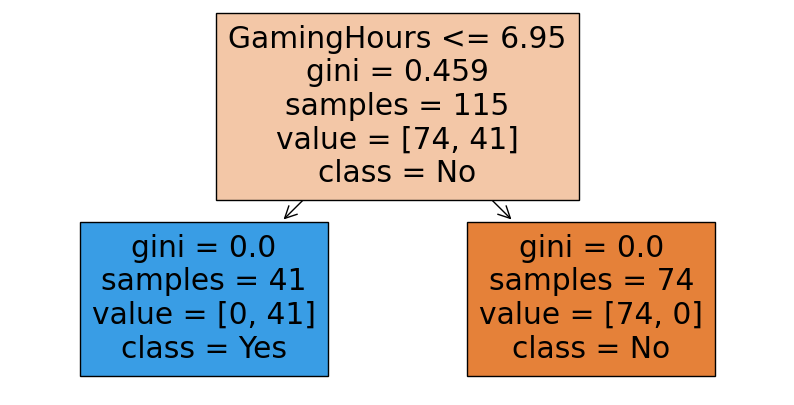

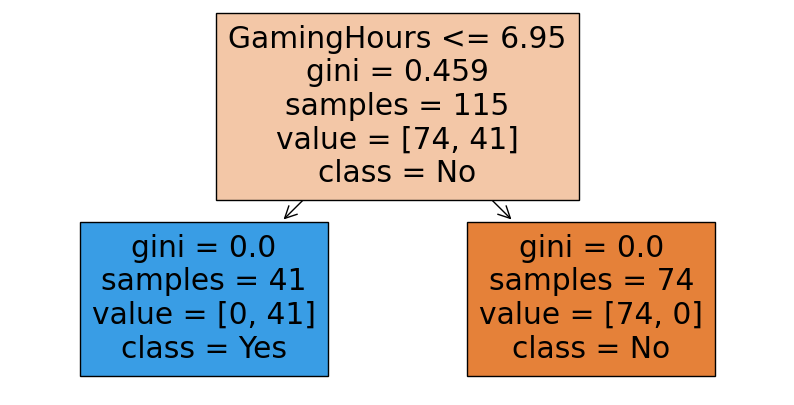

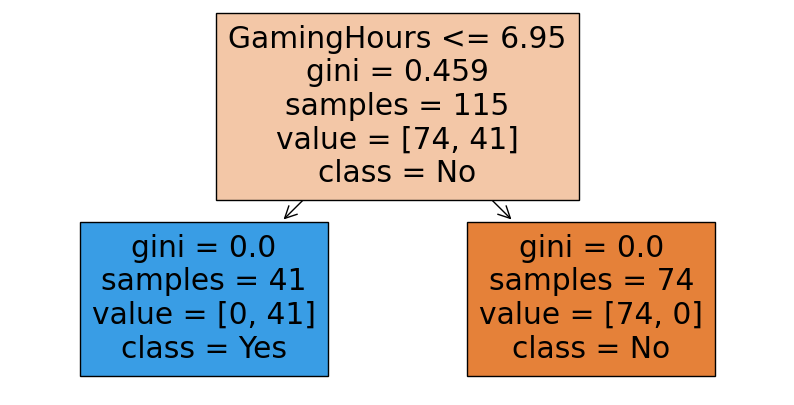

Feature Importances for Default Model:
         Feature  Importance
4   AverageScore         1.0
0            Age         0.0
1  SleepingHours         0.0
2    GamingHours         0.0
3       Distance         0.0
5       Gender_F         0.0
6       Gender_M         0.0
7       Music_No         0.0
8      Music_Yes         0.0
Feature Importances for Model with Fixed Depth:
         Feature  Importance
4   AverageScore         1.0
0            Age         0.0
1  SleepingHours         0.0
2    GamingHours         0.0
3       Distance         0.0
5       Gender_F         0.0
6       Gender_M         0.0
7       Music_No         0.0
8      Music_Yes         0.0
Feature Importances for Model with Fixed Split:
         Feature  Importance
4   AverageScore         1.0
0            Age         0.0
1  SleepingHours         0.0
2    GamingHours         0.0
3       Distance         0.0
5       Gender_F         0.0
6       Gender_M         0.0
7       Music_No         0.0
8      Music_Yes        

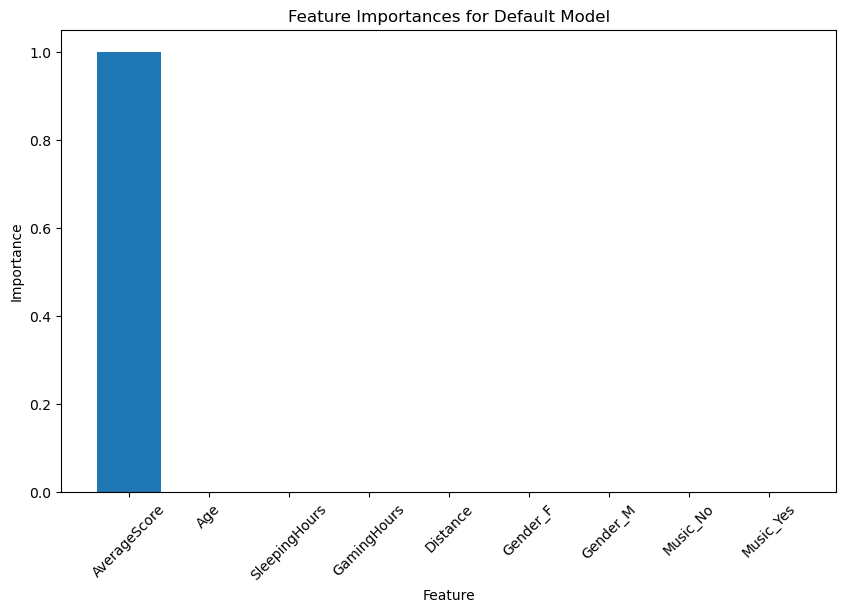

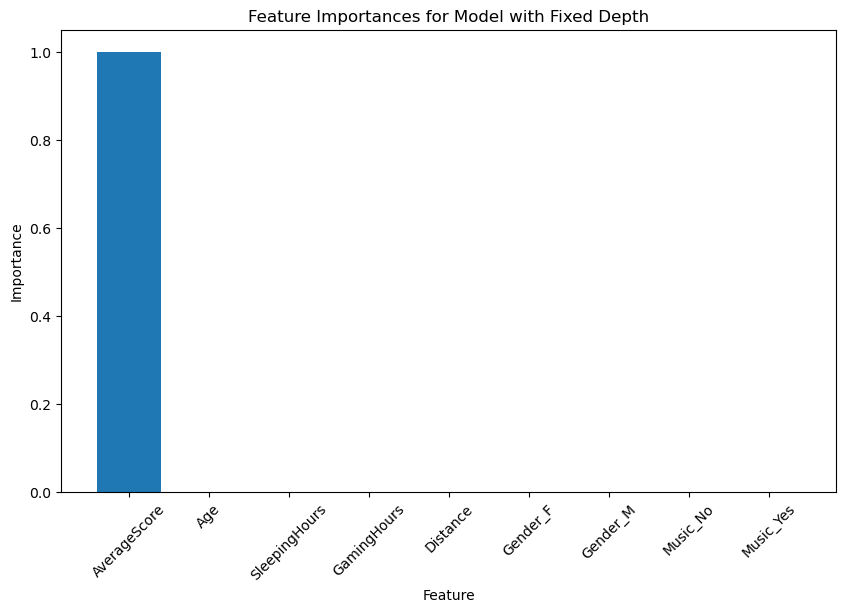

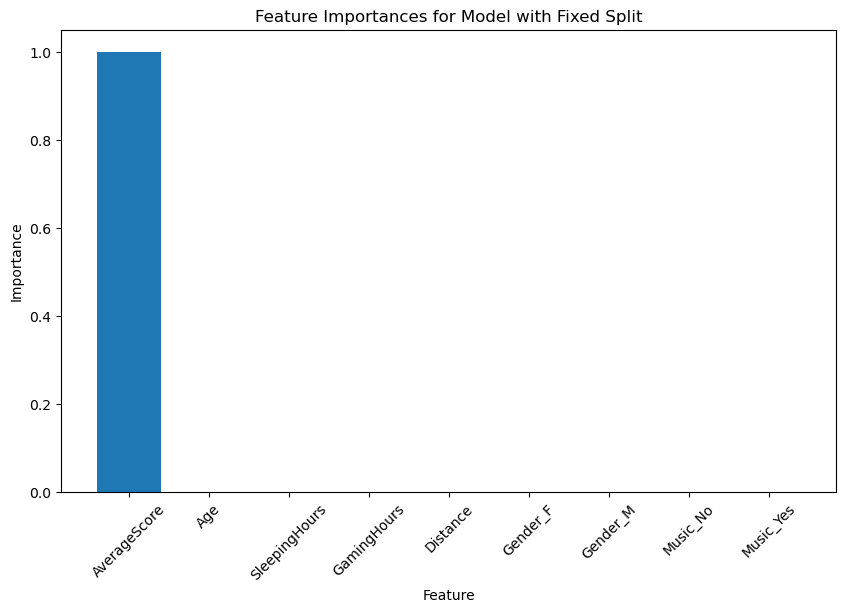

In [6]:
# 1) Model with different parameters
#default model
model_default = DecisionTreeClassifier()
model_default.fit(X_train,y_train)

predictions1 = model_default.predict(X_test)  
score1 = accuracy_score(y_test,predictions1)
print(f"Accuracy Score: {score1}")

#model with fixed depth
model_depth = DecisionTreeClassifier(max_depth = 3)
model_depth.fit(X_train,y_train)

predictions2 = model_depth.predict(X_test)  
score2 = accuracy_score(y_test,predictions2)
print(f"Accuracy Score: {score2}")

#model with fixed split
model_min_split = DecisionTreeClassifier(min_samples_split=20)
model_min_split.fit(X_train,y_train)

predictions3 = model_min_split.predict(X_test)  
score3 = accuracy_score(y_test,predictions3)
print(f"Accuracy Score: {score3}")

# visualize the decision tree
# GamingHours is chosen as the model found splitting based on that is the best options
# values= [no.of samples = No, no.of samples = Yes]
# parent node'class = No as 77 is the majority 
# gini = 0.0 indicates node is pure
# left child node under condition GH is true, right is false
plt.figure(figsize=(10, 5))
#.tolist() convert the Index to a list
plot_tree(model_default, filled=True, feature_names=X.columns.tolist(), class_names=model_default.classes_.tolist())
plt.show()


plt.figure(figsize=(10, 5))
#.tolist() convert the Index to a list
plot_tree(model_depth, filled=True, feature_names=X.columns.tolist(), class_names=model_depth.classes_.tolist())
plt.show()

plt.figure(figsize=(10, 5))
#.tolist() convert the Index to a list
plot_tree(model_min_split, filled=True, feature_names=X.columns.tolist(), class_names=model_min_split.classes_.tolist())
plt.show()

# Get feature importances for the default model
feature_importances_default = model_default.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df_default = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances_default
})

# sort the DataFrame by importance in descending order
feature_importance_df_default = feature_importance_df_default.sort_values(by='Importance', ascending=False)

# Print or display the feature importances for the default model
print("Feature Importances for Default Model:")
print(feature_importance_df_default)

# Get feature importances for the model with fixed depth
feature_importances_depth = model_depth.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df_depth = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances_depth
})

# Sort the DataFrame by importance in descending order
feature_importance_df_depth = feature_importance_df_depth.sort_values(by='Importance', ascending=False)

# Print or display the feature importances for the model with fixed depth
print("Feature Importances for Model with Fixed Depth:")
print(feature_importance_df_depth)

# Get feature importances for the model with fixed split
feature_importances_min_split = model_min_split.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df_min_split = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances_min_split
})

# Sort the DataFrame by importance in descending order
feature_importance_df_min_split = feature_importance_df_min_split.sort_values(by='Importance', ascending=False)

# Print or display the feature importances for the model with fixed split
print("Feature Importances for Model with Fixed Split:")
print(feature_importance_df_min_split)

plt.figure(figsize=(10, 6))
plt.bar(feature_importance_df_default['Feature'], feature_importance_df_default['Importance'])
plt.title('Feature Importances for Default Model')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

# Plot feature importances for the model with fixed depth
plt.figure(figsize=(10, 6))
plt.bar(feature_importance_df_depth['Feature'], feature_importance_df_depth['Importance'])
plt.title('Feature Importances for Model with Fixed Depth')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

# Plot feature importances for the model with fixed split
plt.figure(figsize=(10, 6))
plt.bar(feature_importance_df_min_split['Feature'], feature_importance_df_min_split['Importance'])
plt.title('Feature Importances for Model with Fixed Split')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

In [7]:
#2)Variants
#create a model and train it
#model is an instance of DTC class
model = DecisionTreeClassifier()

# Define a list of dictionaries, each containing hyperparameters for a different decision tree variant
tree_variants = [
    {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1},
    {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2},
    {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 4}
]


# Train and evaluate each decision tree variant
# idx represents index starting from 1
# hyperparameters represents hyperparameters of each variants
# enumerate func iterate over tree_variants
for idx, variant_params in enumerate(tree_variants, 1):
    # Create a decision tree model with specified hyperparameters
    model = DecisionTreeClassifier(**variant_params)
    
    #train model to learn patterns
    #takes 2 datasets (input,output)
    #passing training dataset to train the model
    model.fit(X_train, y_train)


    # Make predictions on the new instance
    predictions =model.predict(X_test)


    #y_test is expected value, prediction is actual value
    #compare predictions y_test with predictions for accuracy
    #return accuracy score between 0~1
    score = accuracy_score(y_test,predictions)
    #precision, recall and f1 expect binary labels(0 or 1 only)
    #change pos_label to 'Yes'
    #Precision focuses on the accuracy of positive predictions.
    #Recall measures the ability to capture all positive instances.
    #F1 score balances precision and recall.
    precision = precision_score(y_test, predictions, pos_label='Yes')
    recall = recall_score(y_test, predictions, pos_label='Yes')
    f1 = f1_score(y_test, predictions,  pos_label='Yes')

    # Print the results for each variant
    print(f"Decision Tree Variant {idx}:")
    print(f"Accuracy Score: {score}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    # seperator line 
    print("="*30) 


Decision Tree Variant 1:
Accuracy Score: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Decision Tree Variant 2:
Accuracy Score: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Decision Tree Variant 3:
Accuracy Score: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy Score: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


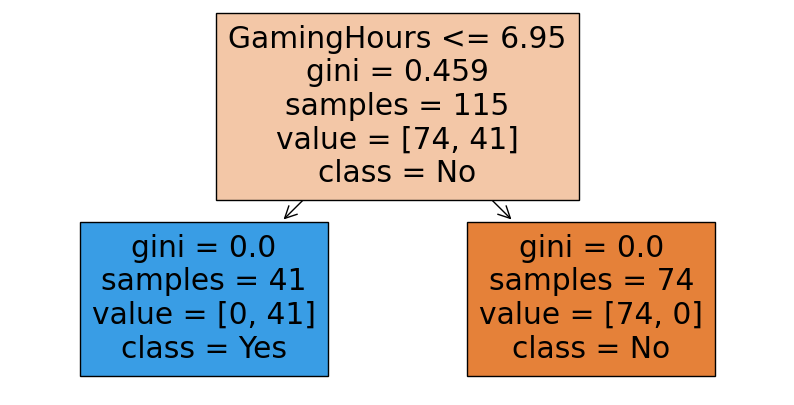

In [8]:
#3) Hyperparameter Tuning

# Define hyperparameter grid
# criterion: measure the quality of a split
# max_depth: maximum depth of decision tree, 'None' : no depth limit, grow until it captures all the details of the training data
# min_samples_split: min no. of samples of each node needed in order to split further
# min_samples_leaf: only split if the resulted leaf node has the chosen amount 
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#Create GridSearchCV object
#model = instance created previously
#param_grid = dataset divided to 5 parts, model is trained and validated 5 times
#can assign different metric like 'precision' etc to scoring
#n_jobs=-1 uses all CPU cores in grid search
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the model to find the best hyperparameters
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_


model_best = DecisionTreeClassifier(**best_params)
#train model to learn patterns
#takes 2 datasets (input,output)
#passing training dataset to train the model
model_best.fit(X_train, y_train)


# Make predictions on the new instance
predictions_best = model_best.predict(X_test)  


#y_test is expected value, prediction is actual value
#compare predictions y_test with predictions for accuracy
#return accuracy score between 0~1
score_best = accuracy_score(y_test, predictions_best)
#precision, recall and f1 expect binary labels(0 or 1 only)
#change pos_label to 'Yes'
#Precision focuses on the accuracy of positive predictions.
#Recall measures the ability to capture all positive instances.
#F1 score balances precision and recall.
precision_best = precision_score(y_test, predictions_best, pos_label='Yes')
recall_best = recall_score(y_test, predictions_best, pos_label='Yes')
f1_best = f1_score(y_test, predictions_best, pos_label='Yes')

print(f"Best Hyperparameters: {best_params}")
print(f"Accuracy Score: {score_best}")
print(f"Precision: {precision_best}")
print(f"Recall: {recall_best}")
print(f"F1 Score: {f1_best}")

# visualize the decision tree
# GamingHours is chosen as the model found splitting based on that is the best options
# values= [no.of samples = No, no.of samples = Yes]
# parent node'class = No as 77 is the majority 
# gini = 0.0 indicates node is pure
# left child node under condition GH is true, right is false
plt.figure(figsize=(10, 5))
#.tolist() convert the Index to a list
plot_tree(model, filled=True, feature_names=X.columns.tolist(), class_names=model.classes_.tolist())
plt.show()

